In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

csv_path = "data/ford_focus_st.csv"

listings = pd.read_csv(csv_path)

listings.head()

,title,price,negotiable,location,year,age,mileage,promoted,url
0,Ford Focus 2.0 EcoBoost ST,16900,False,Lisboa,2017,9,129865,False,https://www.standvirtual.com/carros/anuncio/fo...
1,Ford Focus 2.0 EcoBoost ST,17500,False,Ermesinde,2014,12,127670,False,https://www.standvirtual.com/carros/anuncio/fo...
2,Ford Focus 2.0 ST Ecoboost 250cv c/ novo possi...,15000,False,Paranhos,2014,12,143000,False,https://www.olx.pt/d/anuncio/ford-focus-2-0-st...


In [81]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   title       3 non-null      str  
 1   price       3 non-null      int64
 2   negotiable  3 non-null      bool 
 3   location    3 non-null      str  
 4   year        3 non-null      int64
 5   age         3 non-null      int64
 6   mileage     3 non-null      int64
 7   promoted    3 non-null      bool 
 8   url         3 non-null      str  
dtypes: bool(2), int64(4), str(3)
memory usage: 306.0 bytes


In [82]:
listings.dropna(inplace=True)
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   title       3 non-null      str  
 1   price       3 non-null      int64
 2   negotiable  3 non-null      bool 
 3   location    3 non-null      str  
 4   year        3 non-null      int64
 5   age         3 non-null      int64
 6   mileage     3 non-null      int64
 7   promoted    3 non-null      bool 
 8   url         3 non-null      str  
dtypes: bool(2), int64(4), str(3)
memory usage: 306.0 bytes


In [83]:
listings.describe()

,price,year,age,mileage
count,3.000000,3.000000,3.000000,3.000000
mean,16466.666667,2015.000000,11.000000,133511.666667
std,1305.118130,1.732051,1.732051,8290.106051
min,15000.000000,2014.000000,9.000000,127670.000000
25%,15950.000000,2014.000000,10.500000,128767.500000
50%,16900.000000,2014.000000,12.000000,129865.000000
75%,17200.000000,2015.500000,12.000000,136432.500000
max,17500.000000,2017.000000,12.000000,143000.000000


In [84]:
# listings["negotiable"] = listings["negotiable"].astype(int)
# listings["promoted"] = listings["promoted"].astype(int)
listings = listings[listings['mileage'] > 1000]
listings.drop(columns=["title", "location", "year", "url", "promoted", "negotiable"], inplace=True)


listings.describe()

,price,age,mileage
count,3.000000,3.000000,3.000000
mean,16466.666667,11.000000,133511.666667
std,1305.118130,1.732051,8290.106051
min,15000.000000,9.000000,127670.000000
25%,15950.000000,10.500000,128767.500000
50%,16900.000000,12.000000,129865.000000
75%,17200.000000,12.000000,136432.500000
max,17500.000000,12.000000,143000.000000


In [85]:
listings["log_price"] = np.log(listings["price"] + 1)

listings.drop(columns=["price"], inplace=True)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'mileage'}>],
       [<Axes: title={'center': 'log_price'}>, <Axes: >]], dtype=object)

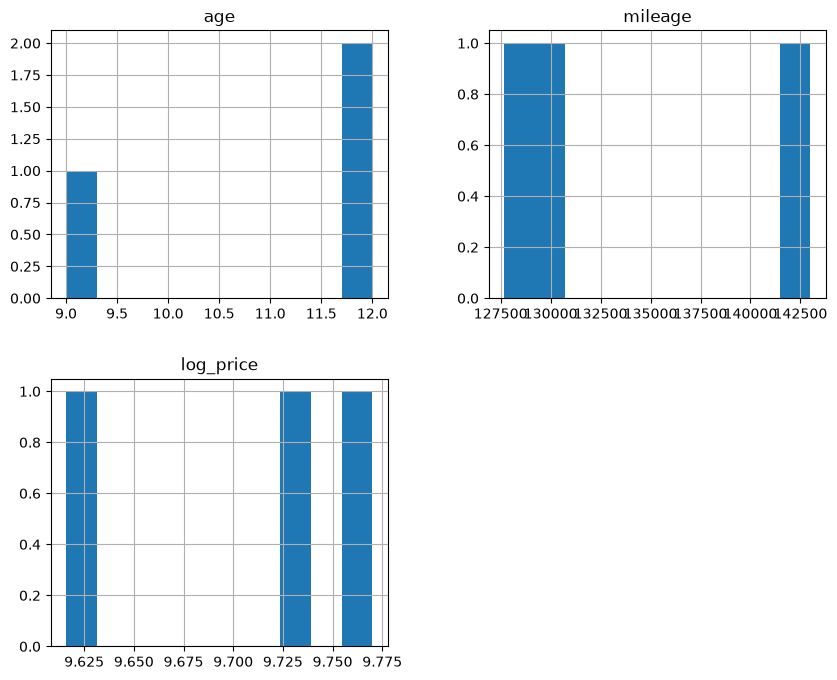

In [86]:
listings.hist(figsize=(10, 8))

<Axes: >

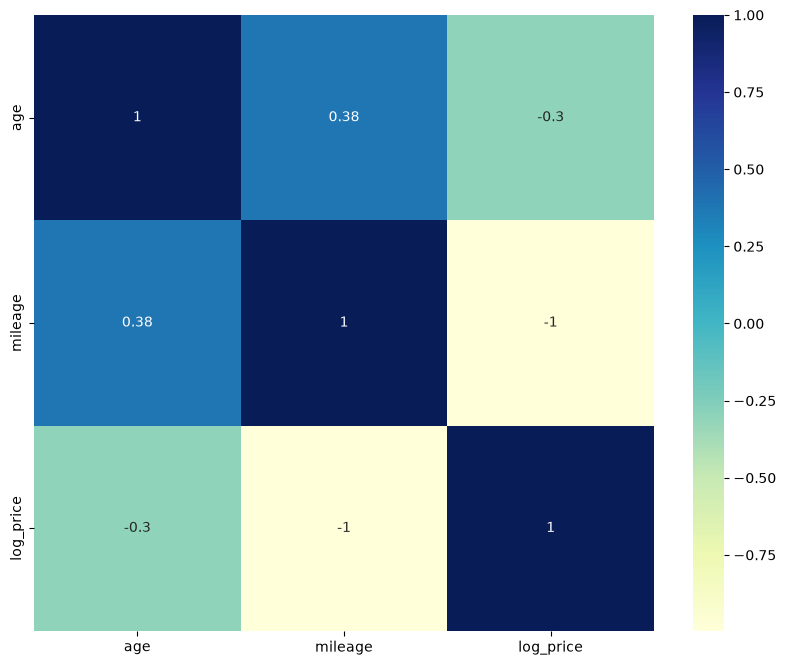

In [87]:
plt.figure(figsize=(10, 8))
sns.heatmap(listings.corr(), annot=True, cmap="YlGnBu")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = listings.drop(columns=["log_price"])
y = listings["log_price"]

X_scaled = scaler.fit_transform(X)

In [ ]:
reg = LinearRegression()
reg.fit(X_scaled, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 0.,-0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['age','mileage']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


Enter the feature values used by the linear model:


c:\Users\supra\Repos\car-price-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\supra\Repos\car-price-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Estimated fair value: €60,198.17
Listed price: €15,000.00
Difference: €-45,198.17 (-75.08%)
Result: The listing looks underpriced.


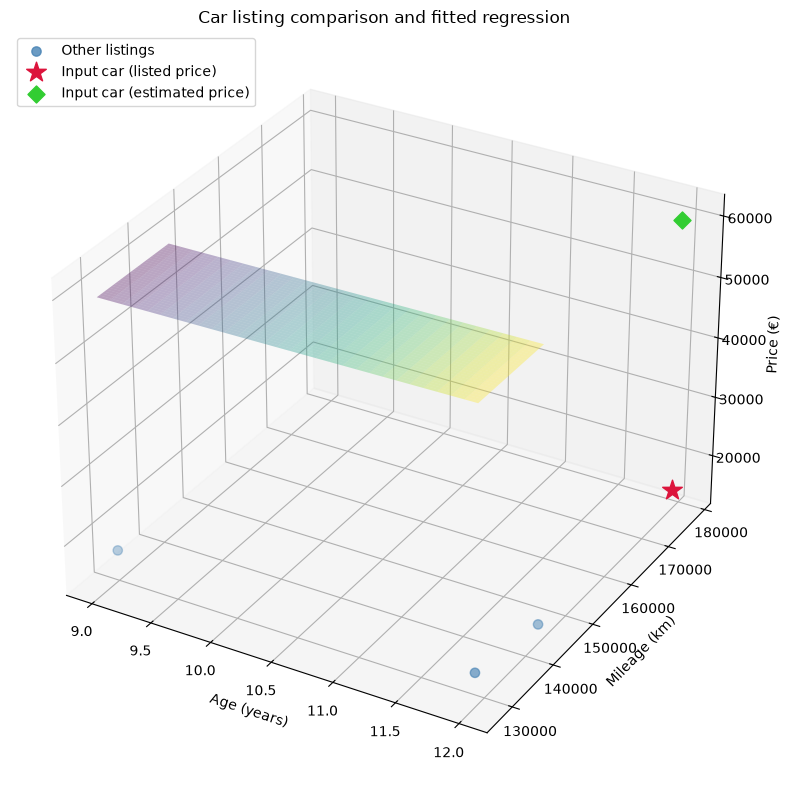

(np.float64(60198.16592283417), 15000.0, 'underpriced')

In [90]:
import pandas as pd
import numpy as np


def plot_listing_comparison(sample, listed_price, fair_value):
    """Plot observed listings, the fitted regression surface, and the input car."""
    age_values = np.linspace(listings["age"].min(), listings["age"].max(), 30)
    mileage_values = np.linspace(listings["mileage"].min(), listings["mileage"].max(), 30)
    age_grid, mileage_grid = np.meshgrid(age_values, mileage_values)

    surface_features = pd.DataFrame(
        {
            "age": age_grid.ravel(),
            "mileage": mileage_grid.ravel(),
        }
    )
    surface_prices = np.expm1(
        reg.predict(scaler.transform(surface_features))
    ).reshape(age_grid.shape)

    figure = plt.figure(figsize=(12, 8))
    axis = figure.add_subplot(111, projection="3d")
    axis.scatter(
        listings["age"],
        listings["mileage"],
        np.expm1(listings["log_price"]),
        color="steelblue",
        s=45,
        alpha=0.8,
        label="Other listings",
    )
    axis.plot_surface(
        age_grid,
        mileage_grid,
        surface_prices,
        cmap="viridis",
        alpha=0.35,
        linewidth=0,
    )
    axis.scatter(
        sample["age"],
        sample["mileage"],
        listed_price,
        color="crimson",
        marker="*",
        s=220,
        label="Input car (listed price)",
    )
    axis.scatter(
        sample["age"],
        sample["mileage"],
        fair_value,
        color="limegreen",
        marker="D",
        s=75,
        label="Input car (estimated price)",
    )

    axis.set_xlabel("Age (years)")
    axis.set_ylabel("Mileage (km)")
    axis.set_zlabel("Price (€)")
    axis.set_title("Car listing comparison and fitted regression")
    axis.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


def assess_listing():
    values = {}
    print("Enter the feature values used by the linear model:")

    for column in X.columns:
        values[column] = float(input(f"{column}: "))

    listed_price = float(input("Listed price: "))

    sample = pd.DataFrame([values], columns=X.columns)
    sample_scaled = scaler.transform(sample)
    predicted_log_price = reg.predict(sample_scaled)[0]
    fair_value = np.expm1(predicted_log_price)

    difference = listed_price - fair_value
    percent_diff = (difference / fair_value) * 100 if fair_value != 0 else 0

    if abs(difference) < 1e-6:
        status = "fairly priced"
    elif difference > 0:
        status = "overpriced"
    else:
        status = "underpriced"

    print(f"\nEstimated fair value: €{fair_value:,.2f}")
    print(f"Listed price: €{listed_price:,.2f}")
    print(f"Difference: €{difference:,.2f} ({percent_diff:+.2f}%)")
    print(f"Result: The listing looks {status}.")

    plot_listing_comparison(sample.iloc[0], listed_price, fair_value)
    return fair_value, listed_price, status


assess_listing()